[[ 0.  -1.  -0.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.  -0.5 -1. ]
 [-1.   0.  -1.  -0.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.  -0.5]
 [-0.5 -1.   0.  -1.  -0.5  0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0. ]
 [ 0.  -0.5 -1.   0.  -1.  -0.5  0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.  -0.5 -1.   0.  -1.  -0.5  0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.  -0.5 -1.   0.  -1.  -0.5  0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.  -0.5 -1.   0.  -1.  -0.5  0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.  -0.5 -1.   0.  -1.  -0.5  0.   0.   0.   0.
   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.  -0.5 -1.   0.  -1.  -0.5  0.   0.   0.
   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.  -0.5 -1.   0.  -1.  -0.5  0

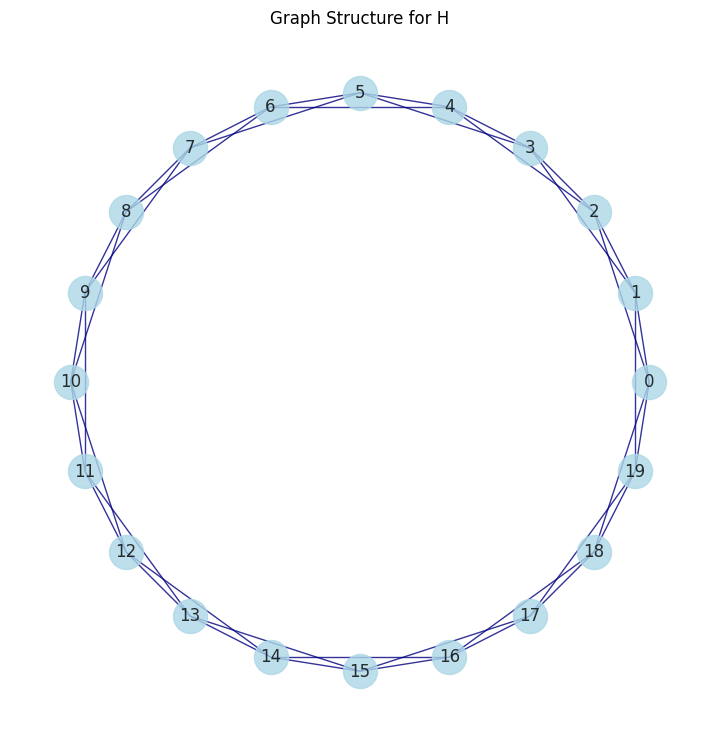

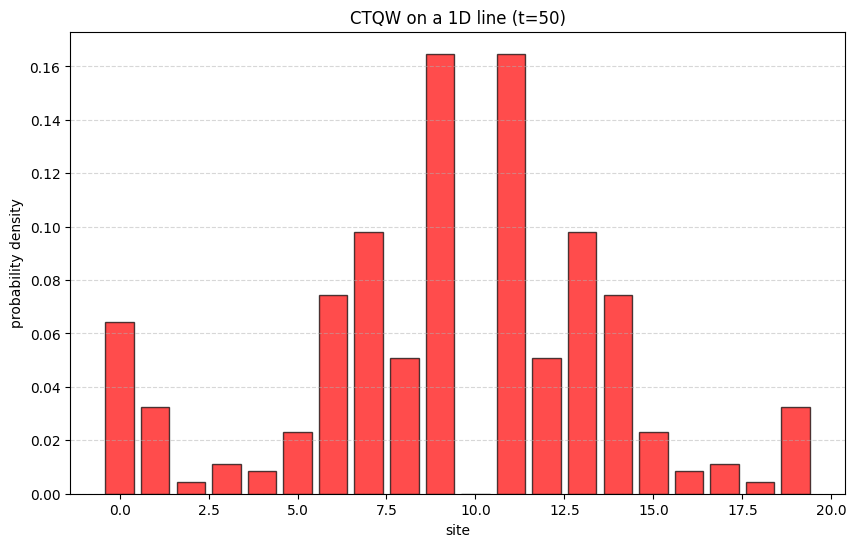

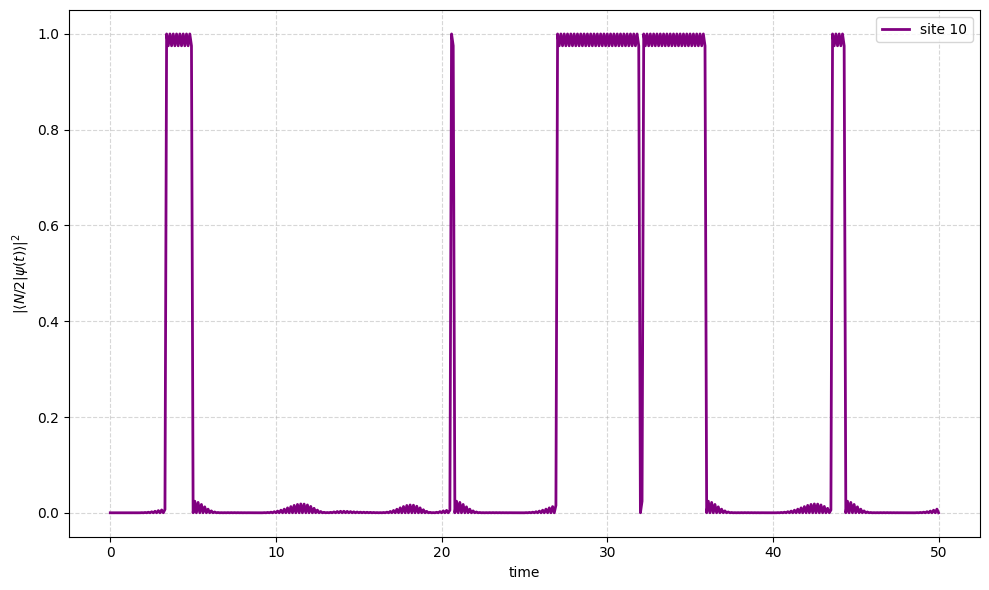

In [ ]:
import numpy as np # for doing stuff with numbers
import matplotlib.pyplot as plt # for plotting
from scipy.linalg import expm # this we need for the time evolution operator


########################################## PROJECTIVE MEASUREMENT FUNCTION

import random
random.seed(13)

def on_site_PVM(state, target_site):

    # prepare probability to extract outcome and empty state to write the result
    prob_success = np.abs(state[target_site]) ** 2
    collapsed_state = np.zeros_like(state) # that is, np.zeros(len(psi), dtype=psi.dtype)
    detection_successful = False

    if (random.random()>=prob_success):
        # print(f"Walker is NOT at site {target_site}.")
        # projecting on the complementary subspace
        collapsed_state = state.copy()
        collapsed_state[target_site] = 0.0 
        # renormalize
        norm = np.linalg.norm(collapsed_state)
        if norm > 0:
            collapsed_state = collapsed_state/norm
    else:
        print(f"Success! Walker at site {target_site}.")
        collapsed_state[target_site] = state[target_site] / np.sqrt(prob_success)
        detection_successful = True

    return collapsed_state, detection_successful


########################################## FUNCTION TO SHOW GRAPHS

def plot_graph_from_Hamiltonian(matrix):

    import networkx as nx # to make a picture of the graph structure... (don't wanna leave connectivity unchecked)
    G = nx.Graph()
    num_sites = matrix.shape[0]
    # define sites
    for i in range(num_sites):
        G.add_node(i)
    # find and add edges
    for i in range(num_sites):
        for j in range(i+1, num_sites):
            if np.abs(matrix[i,j]) > 1e-12:
                G.add_edge(i,j)

    pos = nx.circular_layout(G)
    plt.figure(figsize=(7,7))

    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=600, edge_color='navy', alpha=0.8)
    plt.title(f"Graph Structure for H")



##########################################
##########################################
########################################## MAIN CODE
##########################################
##########################################

##########################################
# 1. define parameters for a qw on a line
##########################################
num_sites = 20
t = 50 # duration of the evolution
# couplings and constants relevant to H
# decay_constant = 0.0
on_site_energy = 0.0
gamma_1 = 1.0
gamma_2 = 0.5

##########################################
# 2. Laplacian matrix for a ring (L = D - A)
##########################################
# on-site energies
diag = 2 * np.eye(num_sites) * on_site_energy
# first neighbor hopping
first_n_upper = -gamma_1 * np.eye(num_sites, k=1)
first_n_lower = -gamma_1 * np.eye(num_sites, k=-1)
second_n_upper = -gamma_2 * np.eye(num_sites, k=2)
second_n_lower = -gamma_2 * np.eye(num_sites, k=-2)

# sum
L = diag + first_n_upper + first_n_lower + second_n_upper + second_n_lower
# add periodic boundary conditions (it becomes a ring...)
L += -gamma_1*(np.eye(num_sites, k=(num_sites-1))+np.eye(num_sites, k=-(num_sites-1)))
L += -gamma_2*(np.eye(num_sites, k=(num_sites-2))+np.eye(num_sites, k=-(num_sites-2)))
# check 
print(L)

##########################################
# 3. initialization of the state
##########################################

psi_0 = np.zeros(num_sites, dtype=complex)
psi_0[0] = 1.0 # start at node 0

##########################################
# 4. time evolution (time-indep. H) + PVM
##########################################
gamma = 1.0 # hopping rate
H = gamma * L
plot_graph_from_Hamiltonian(L)
interval = 0.1 # time interval
U = expm(-1j * H * interval) # evolution time step

time = 0.0 # initialize evolution
psi_step = psi_0 # initialize state by copying initial condition

target_site = num_sites // 2 # track the other end of the ring 
time_points = [time]
target_probs = [np.abs(psi_step[target_site])**2]

tau = 0.2 # PVM once every tau
steps_for_tau = int(round(tau / interval)) 
print(f'steps for tau = {steps_for_tau}')
step_counter = 0 # initialize

number_of_detections = 0
while(time<t):
    time += interval
    step_counter += 1
    psi_step = np.dot(U,psi_step) # free evolution - UNITARY step
    if (step_counter % steps_for_tau == 0):
        psi_step, success = on_site_PVM(psi_step, int(num_sites/2)) # measurement step gives a 2-ple! have to save success
        #print(f"measuring at time = {time}")
        if success:
            number_of_detections += 1
            if number_of_detections == 1:
                print(f'=============== First detection at time {time}! ===============')
    time_points.append(time)
    target_probs.append(np.abs(psi_step[target_site])**2)


##########################################
# 5. probabilities calculation
##########################################
probabilities = np.abs(psi_step) ** 2 
# no need to project it: this is done INTERNALLY

##########################################
# 6. plot
##########################################
positions = np.arange(0, num_sites) # this is inherently a "vector"

plt.figure(figsize=(10, 6))
plt.bar(positions, probabilities, color = 'red', edgecolor = 'black', alpha = 0.7)
plt.title(f"CTQW on a 1D line (t={t})")
plt.xlabel("site")
plt.ylabel("probability density")
plt.grid(axis='y', linestyle='--',alpha=0.5)
plt.show()

##########################################
# 7. plot
##########################################
plt.figure(figsize=(10,6))
plt.plot(time_points, target_probs, color='purple', linewidth=2, label=f'site {target_site}' )
plt.xlabel("time")
plt.ylabel(r"$|\langle N/2 | \psi(t) \rangle|^2$")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


##########################################
# USEFUL NOTES
##########################################
# interval = 0.01 to recover zeno effect
